# HOGENOM likelihood optimization

This notebook uses the lean `GeneReconModel` API to load the HOGENOM species tree and gene-tree distributions, evaluate the full negative log-likelihood, and optimize the likelihood end to end with Adam.

Set `MODE` to `global`, `specieswise`, or `genewise`.

In [1]:
from pathlib import Path
import json
import math
import os
import subprocess
import time

import sys

import numpy as np
import torch

CWD = Path.cwd()
REPO = CWD if (CWD / "gpurec").exists() else CWD.parent if (CWD.parent / "gpurec").exists() else CWD
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from gpurec import GeneReconModel, SolverOptions, clamp_log_rate_, project_rate_gradient_

torch.set_float32_matmul_precision("high")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE != "cuda":
    raise RuntimeError("The current lean HOGENOM likelihood path requires CUDA/Triton.")
DEVICE


'cuda'

## Paths and run settings

In [2]:
def find_hogenom_root() -> Path:
    env_root = os.environ.get("HOGENOM_ROOT")
    candidates = []
    if env_root:
        candidates.append(Path(env_root).expanduser())
    candidates.extend([
        REPO / "tests/data",
        REPO / "tests/data/HOGENOM/hogenom",
        REPO / "tests/data/HOGENOM",
        REPO / "tests/data/hogenom",
        REPO / "data/HOGENOM/hogenom",
    ])
    for candidate in candidates:
        if (candidate / "hogenom_S.tree").exists() and (candidate / "hogenom_trees").is_dir():
            return candidate
    raise FileNotFoundError(
        "Set HOGENOM_ROOT, or set both HOGENOM_SPECIES_TREE and "
        "HOGENOM_GENE_TREE_DIR, before running this notebook."
    )

species_tree_env = os.environ.get("HOGENOM_SPECIES_TREE")
gene_tree_dir_env = os.environ.get("HOGENOM_GENE_TREE_DIR")
if species_tree_env or gene_tree_dir_env:
    if not (species_tree_env and gene_tree_dir_env):
        raise ValueError("Set both HOGENOM_SPECIES_TREE and HOGENOM_GENE_TREE_DIR, or neither.")
    SPECIES_TREE = Path(species_tree_env).expanduser()
    GENE_TREE_DIR = Path(gene_tree_dir_env).expanduser()
    HOGENOM_ROOT = GENE_TREE_DIR.parent
else:
    HOGENOM_ROOT = find_hogenom_root()
    SPECIES_TREE = HOGENOM_ROOT / "hogenom_S.tree"
    GENE_TREE_DIR = HOGENOM_ROOT / "hogenom_trees"

MODE = os.environ.get("GPUREC_MODE", "specieswise")  # global, specieswise, or genewise
MAX_FAMILIES = None  # set to an int for a fast smoke run

STEPS = 1000
LR = 2
PRINT_EVERY = 10
CLIP_GRAD_NORM = 1_000.0
MIN_RATE = 1e-10
MAX_RATE = 2.0
OPTIMIZER_NAME = "Adam"  # Adam, Adagrad, LBFGSB, or Adagrad-LBFGSB

# L-BFGS-B controls. The SciPy path optimizes bounded flattened theta values
# and restarts when adaptive solver knobs are increased, which resets BFGS
# curvature history for the new solver regime.
LBFGSB_MAXLS = 20
LBFGSB_GTOL = 1e-5
LBFGSB_FTOL = 1e-9
LBFGSB_MAXFUN_MULTIPLIER = 25

# Adaptive solver controls. When the loss stalls, increase solver accuracy
# and reset optimizer state so stale moments do not dominate the new regime.
STALL_PATIENCE = 20
STALL_REL_IMPROVEMENT = 1e-3
STALL_ABS_IMPROVEMENT = 0.0
PI_ITERS_INCREMENT = 16
PI_ITERS_MAX = 32
NEUMANN_TERMS_INCREMENT = 16
NEUMANN_TERMS_MAX = 32
RESET_OPTIMIZER_ON_STALL = True

# Solver controls. These can also be changed during optimization with
# model.configure_solver(...) or direct model.solver_options.* assignment.
E_INIT = -1000
E_MAX_ITER = 2000
E_TOL = 1e-8
PI_ITERS = 16
NEUMANN_TERMS = 16
BICGSTAB_MAX_ITER = 500
BICGSTAB_TOL = 1e-7
BICGSTAB_BREAKDOWN_TOL = 1e-30
ADJOINT_PRUNING_THRESHOLD = 1e-6
USE_ADJOINT_PRUNING = True
PIBAR_SIDE_THRESHOLD = 0.0

species_tree = SPECIES_TREE
gene_trees = sorted(GENE_TREE_DIR.glob("*.trees"))
if MAX_FAMILIES is not None:
    gene_trees = gene_trees[:MAX_FAMILIES]

if not species_tree.exists():
    raise FileNotFoundError(f"species tree not found: {species_tree}")
if not gene_trees:
    raise FileNotFoundError(f"no *.trees files found in {GENE_TREE_DIR}")

{
    "mode": MODE,
    "device": DEVICE,
    "species_tree": str(species_tree),
    "gene_tree_dir": str(GENE_TREE_DIR),
    "families": len(gene_trees),
    "min_rate": MIN_RATE,
    "max_rate": MAX_RATE,
    "optimizer": OPTIMIZER_NAME,
    "stall_patience": STALL_PATIENCE,
    "solver": {
        "e_max_iter": E_MAX_ITER,
        "e_tol": E_TOL,
        "pi_iters": PI_ITERS,
        "neumann_terms": NEUMANN_TERMS,
        "bicgstab_max_iter": BICGSTAB_MAX_ITER,
        "bicgstab_tol": BICGSTAB_TOL,
    },
}


{'mode': 'specieswise',
 'device': 'cuda',
 'species_tree': '/home/enzo/Documents/git/gpurec/gpurec/tests/data/hogenom_S.tree',
 'gene_tree_dir': '/home/enzo/Documents/git/gpurec/gpurec/tests/data/hogenom_trees',
 'families': 1055,
 'min_rate': 1e-10,
 'max_rate': 2.0,
 'optimizer': 'Adam',
 'stall_patience': 20,
 'solver': {'e_max_iter': 2000,
  'e_tol': 1e-08,
  'pi_iters': 16,
  'neumann_terms': 16,
  'bicgstab_max_iter': 500,
  'bicgstab_tol': 1e-07}}

## Native extension check

In [3]:
preprocess_so = REPO / "crates/gpurec-preprocess/target/release/libgpurec_preprocess.so"

if not preprocess_so.exists():
    subprocess.run(["cargo", "build", "--release"], cwd=REPO / "crates/gpurec-preprocess", check=True)

preprocess_so.exists()

True

## Build the model

In [4]:
torch.cuda.empty_cache()
if DEVICE == "cuda":
    torch.cuda.reset_peak_memory_stats()

t0 = time.perf_counter()
solver_options = SolverOptions(
    e_init=E_INIT,
    e_max_iter=E_MAX_ITER,
    e_tol=E_TOL,
    pi_iters=PI_ITERS,
    neumann_terms=NEUMANN_TERMS,
    bicgstab_max_iter=BICGSTAB_MAX_ITER,
    bicgstab_tol=BICGSTAB_TOL,
    bicgstab_breakdown_tol=BICGSTAB_BREAKDOWN_TOL,
    adjoint_pruning_threshold=ADJOINT_PRUNING_THRESHOLD,
    use_adjoint_pruning=USE_ADJOINT_PRUNING,
    pibar_side_threshold=PIBAR_SIDE_THRESHOLD,
)
model = GeneReconModel(
    species_tree,
    gene_trees,
    mode=MODE,
    device=DEVICE,
    family_chunk_size=300,
    clade_budget=315_000,
    batch_packing="depth_first_fit",
    max_wave_size=8192,
    solver_options=solver_options,
)
clamp_log_rate_(model.theta, min_rate=MIN_RATE, max_rate=MAX_RATE)
if DEVICE == "cuda":
    torch.cuda.synchronize()
build_s = time.perf_counter() - t0

{
    "build_s": build_s,
    "theta_shape": tuple(model.theta.shape),
    "batches": [len(batch) for batch in model.family_batches],
    "waves": [len(static.wave_layout["wave_metas"]) for static in model.batch_statics],
    "solver_options": model.solver_options.__dict__,
}

{'build_s': 7.195129250176251,
 'theta_shape': (1325, 3),
 'batches': [91, 146, 300, 300, 218],
 'waves': [102, 65, 48, 30, 13],
 'solver_options': {'e_init': -1000,
  'e_max_iter': 2000,
  'e_tol': 1e-08,
  'pi_iters': 16,
  'neumann_terms': 16,
  'bicgstab_max_iter': 500,
  'bicgstab_tol': 1e-07,
  'bicgstab_breakdown_tol': 1e-30,
  'adjoint_pruning_threshold': 1e-06,
  'use_adjoint_pruning': True,
  'pibar_side_threshold': 0.0}}

## Initial likelihood and gradient

In [5]:
model.zero_grad(set_to_none=True)
t0 = time.perf_counter()
loss0 = model()
loss0.backward()
if DEVICE == "cuda":
    torch.cuda.synchronize()
eval_s = time.perf_counter() - t0

grad_norm0 = float(model.theta.grad.detach().norm().cpu())
peak_gib = torch.cuda.max_memory_allocated() / 1024**3 if DEVICE == "cuda" else None

{
    "initial_nll_bits": float(loss0.detach().cpu()),
    "grad_norm": grad_norm0,
    "eval_s": eval_s,
    "peak_gib": peak_gib,
}

{'initial_nll_bits': 2305222.25,
 'grad_norm': 1992.7667236328125,
 'eval_s': 2.3880536949727684,
 'peak_gib': 5.898375034332275}

## Optimize

Set `OPTIMIZER_NAME` above to `Adam`, `Adagrad`, `LBFGSB`, or `Adagrad-LBFGSB`. The hybrid mode starts with projected-gradient Adagrad and switches to bounded SciPy L-BFGS-B once `neumann_terms` reaches `NEUMANN_TERMS_MAX`.


In [ ]:
def normalized_optimizer_name(name: str) -> str:
    name = str(name).strip().lower().replace("_", "-")
    if name in {"adam", "adagrad"}:
        return name
    if name in {"lbfgsb", "l-bfgs-b", "lbfgs-b", "bfgsb"}:
        return "lbfgsb"
    if name in {
        "adagrad-lbfgsb",
        "adagrad-l-bfgs-b",
        "adagrad-lbfgs-b",
        "adagrad-then-lbfgsb",
        "adagrad-then-l-bfgs-b",
    }:
        return "adagrad-lbfgsb"
    raise ValueError(
        "unsupported optimizer %r; use 'Adam', 'Adagrad', 'LBFGSB', or 'Adagrad-LBFGSB'" % (name,)
    )


def make_optimizer(name, params, *, lr):
    name = normalized_optimizer_name(name)
    if name == "adam":
        return torch.optim.Adam(params, lr=lr)
    if name == "adagrad":
        return torch.optim.Adagrad(params, lr=lr)
    raise ValueError("make_optimizer is only used for Adam/Adagrad")


def log2_bounds(min_rate, max_rate):
    lower = math.log2(float(min_rate))
    upper = None if max_rate is None else math.log2(float(max_rate))
    return lower, upper


def scipy_lbfgsb_bounds(theta: torch.Tensor, *, min_rate, max_rate):
    lower, upper = log2_bounds(min_rate, max_rate)
    return [(lower, upper)] * int(theta.numel())


@torch.no_grad()
def load_flat_theta_(model, flat_theta, *, min_rate, max_rate):
    flat_theta = np.asarray(flat_theta, dtype=np.float64)
    theta_cpu = torch.from_numpy(flat_theta.reshape(tuple(model.theta.shape)))
    theta_device = theta_cpu.to(device=model.theta.device, dtype=model.theta.dtype)
    model.theta.copy_(theta_device)
    clamp_log_rate_(model.theta, min_rate=min_rate, max_rate=max_rate)


def flat_theta_numpy(model) -> np.ndarray:
    return model.theta.detach().cpu().double().numpy().reshape(-1).copy()


def projected_grad_norm_for_diagnostics(model, *, min_rate, max_rate) -> float:
    if model.theta.grad is None:
        return float("nan")
    grad = model.theta.grad.detach().clone()
    project_rate_gradient_(model.theta, grad, min_rate=min_rate, max_rate=max_rate)
    return float(grad.norm().detach().cpu())


def bump_solver_options(
    model,
    *,
    pi_increment,
    pi_max,
    neumann_increment,
    neumann_max,
):
    old_pi = int(model.solver_options.pi_iters)
    old_neumann = int(model.solver_options.neumann_terms)
    pi_cap = int(pi_max)
    if pi_cap % 2:
        pi_cap -= 1
    pi_cap = max(2, pi_cap)
    new_pi = min(pi_cap, old_pi + int(pi_increment))
    if new_pi % 2:
        new_pi += 1
    new_pi = min(pi_cap, new_pi)
    new_neumann = min(int(neumann_max), old_neumann + int(neumann_increment))
    changed = new_pi != old_pi or new_neumann != old_neumann
    if changed:
        model.configure_solver(pi_iters=new_pi, neumann_terms=new_neumann)
        model.clear_warm_starts()
    return {
        "solver_changed": changed,
        "old_pi_iters": old_pi,
        "new_pi_iters": int(model.solver_options.pi_iters),
        "old_neumann_terms": old_neumann,
        "new_neumann_terms": int(model.solver_options.neumann_terms),
    }


def should_increase_solver(history, *, patience, rel_improvement, abs_improvement):
    if patience <= 0 or len(history) <= patience:
        return False, None
    earlier = history[-patience - 1]["nll_bits"]
    current = history[-1]["nll_bits"]
    improvement = earlier - current
    required = max(float(abs_improvement), float(rel_improvement) * max(abs(earlier), 1.0))
    return improvement <= required, {
        "window_improvement_bits": improvement,
        "required_improvement_bits": required,
        "window_start_nll_bits": earlier,
    }


def maybe_bump_solver_after_stall(
    history,
    model,
    *,
    step,
    last_solver_adjust_step,
    stall_patience,
    stall_rel_improvement,
    stall_abs_improvement,
    pi_iters_increment,
    pi_iters_max,
    neumann_terms_increment,
    neumann_terms_max,
):
    if step - last_solver_adjust_step < stall_patience:
        return False, None, last_solver_adjust_step
    stalled, stall_info = should_increase_solver(
        history,
        patience=stall_patience,
        rel_improvement=stall_rel_improvement,
        abs_improvement=stall_abs_improvement,
    )
    if not stalled:
        return False, None, last_solver_adjust_step
    bump = bump_solver_options(
        model,
        pi_increment=pi_iters_increment,
        pi_max=pi_iters_max,
        neumann_increment=neumann_terms_increment,
        neumann_max=neumann_terms_max,
    )
    if bump["solver_changed"]:
        last_solver_adjust_step = step
    info = {**bump, **(stall_info or {})}
    return bool(bump["solver_changed"]), info, last_solver_adjust_step


def evaluate_loss_and_grad(
    model,
    *,
    min_rate,
    max_rate,
    project_gradient_for_step: bool,
    check_finite: bool = True,
    compute_projected_grad_norm: bool = False,
):
    model.zero_grad(set_to_none=True)
    model.theta.grad = None
    loss = model()
    loss.backward()
    if project_gradient_for_step:
        project_rate_gradient_(model.theta, min_rate=min_rate, max_rate=max_rate)
    if model.theta.grad is None:
        raise RuntimeError("missing theta gradient")
    grad = model.theta.grad.detach()
    if check_finite and (not torch.isfinite(loss).all() or not torch.isfinite(grad).all()):
        raise FloatingPointError("non-finite loss or gradient")
    projected_grad_norm = None
    if compute_projected_grad_norm:
        projected_grad_norm = projected_grad_norm_for_diagnostics(
            model,
            min_rate=min_rate,
            max_rate=max_rate,
        )
    return loss, grad, projected_grad_norm


def run_first_order_phase(
    model,
    *,
    steps,
    optimizer_name,
    lr,
    clip_grad_norm,
    min_rate,
    max_rate,
    stall_patience,
    stall_rel_improvement,
    stall_abs_improvement,
    pi_iters_increment,
    pi_iters_max,
    neumann_terms_increment,
    neumann_terms_max,
    reset_optimizer_on_stall,
    print_every,
    history=None,
    previous_loss=None,
    start_step=1,
    optimizer_reset_count=0,
    last_solver_adjust_step=0,
    phase=None,
    stop_when_neumann_max=False,
):
    optimizer = make_optimizer(optimizer_name, [model.theta], lr=lr)
    display_name = normalized_optimizer_name(optimizer_name)
    phase = phase or display_name
    clamp_log_rate_(model.theta, min_rate=min_rate, max_rate=max_rate)
    if history is None:
        history = []

    last_step = int(start_step) - 1
    for offset in range(int(steps)):
        step = int(start_step) + offset
        last_step = step
        optimizer.zero_grad(set_to_none=True)
        t0 = time.perf_counter()
        loss, _grad, _projected_grad_norm = evaluate_loss_and_grad(
            model,
            min_rate=min_rate,
            max_rate=max_rate,
            project_gradient_for_step=False,
            check_finite=False,
            compute_projected_grad_norm=False,
        )
        grad_norm = float(model.theta.grad.detach().norm().cpu())
        project_rate_gradient_(model.theta, min_rate=min_rate, max_rate=max_rate)
        projected_grad_norm = float(model.theta.grad.detach().norm().cpu())
        torch.nn.utils.clip_grad_norm_([model.theta], clip_grad_norm)
        projected_grad_norm_after_clip = float(model.theta.grad.detach().norm().cpu())
        optimizer.step()
        clamp_log_rate_(model.theta, min_rate=min_rate, max_rate=max_rate)
        if DEVICE == "cuda":
            torch.cuda.synchronize()
        step_s = time.perf_counter() - t0

        loss_value = float(loss.detach().cpu())
        delta = None if previous_loss is None else loss_value - previous_loss
        previous_loss = loss_value
        row = {
            "step": step,
            "nll_bits": loss_value,
            "delta_bits": delta,
            "grad_norm": grad_norm,
            "projected_grad_norm": projected_grad_norm,
            "projected_grad_norm_after_clip": projected_grad_norm_after_clip,
            "theta_min": float(model.theta.detach().min().cpu()),
            "theta_max": float(model.theta.detach().max().cpu()),
            "e_max_iter": model.solver_options.e_max_iter,
            "e_tol": model.solver_options.e_tol,
            "pi_iters": model.solver_options.pi_iters,
            "neumann_terms": model.solver_options.neumann_terms,
            "bicgstab_max_iter": model.solver_options.bicgstab_max_iter,
            "bicgstab_tol": model.solver_options.bicgstab_tol,
            "lr": optimizer.param_groups[0]["lr"],
            "optimizer": display_name,
            "optimizer_phase": phase,
            "optimizer_reset_count": optimizer_reset_count,
            "solver_changed": False,
            "step_s": step_s,
        }
        history.append(row)

        solver_changed, stall_update, last_solver_adjust_step = maybe_bump_solver_after_stall(
            history,
            model,
            step=step,
            last_solver_adjust_step=last_solver_adjust_step,
            stall_patience=stall_patience,
            stall_rel_improvement=stall_rel_improvement,
            stall_abs_improvement=stall_abs_improvement,
            pi_iters_increment=pi_iters_increment,
            pi_iters_max=pi_iters_max,
            neumann_terms_increment=neumann_terms_increment,
            neumann_terms_max=neumann_terms_max,
        )
        if stall_update:
            row.update(stall_update)
        if solver_changed and reset_optimizer_on_stall:
            optimizer = make_optimizer(optimizer_name, [model.theta], lr=lr)
            optimizer_reset_count += 1
            row["optimizer_reset_count"] = optimizer_reset_count
            row["optimizer_restarted"] = True

        should_transition = stop_when_neumann_max and int(model.solver_options.neumann_terms) >= int(neumann_terms_max)
        if should_transition:
            row["phase_transition"] = "neumann_terms_max_reached"

        if step == 1 or step % print_every == 0 or row["solver_changed"] or should_transition:
            print(
                f"step={step:04d} nll={loss_value:.6f} "
                f"delta={delta if delta is not None else float('nan'):.6f} "
                f"grad_norm={row['grad_norm']:.3g} "
                f"projected_grad_norm={row['projected_grad_norm']:.3g} "
                f"pi={row['pi_iters']} "
                f"neumann={row['neumann_terms']} "
                f"optimizer={display_name} "
                f"phase={phase} "
                f"resets={optimizer_reset_count} "
                f"step_s={step_s:.3f}"
            )
        if should_transition:
            print(
                f"switching optimizer Adagrad -> LBFGSB at step={step:04d} "
                f"because neumann_terms reached {model.solver_options.neumann_terms}"
            )
            break

    return history, previous_loss, last_step, optimizer_reset_count, last_solver_adjust_step


def optimize_likelihood_first_order(
    model,
    *,
    steps,
    optimizer_name="Adam",
    lr=1.0,
    clip_grad_norm,
    min_rate,
    max_rate,
    stall_patience,
    stall_rel_improvement,
    stall_abs_improvement,
    pi_iters_increment,
    pi_iters_max,
    neumann_terms_increment,
    neumann_terms_max,
    reset_optimizer_on_stall=True,
    print_every=10,
):
    history, _previous_loss, _last_step, _resets, _last_solver_adjust_step = run_first_order_phase(
        model,
        steps=steps,
        optimizer_name=optimizer_name,
        lr=lr,
        clip_grad_norm=clip_grad_norm,
        min_rate=min_rate,
        max_rate=max_rate,
        stall_patience=stall_patience,
        stall_rel_improvement=stall_rel_improvement,
        stall_abs_improvement=stall_abs_improvement,
        pi_iters_increment=pi_iters_increment,
        pi_iters_max=pi_iters_max,
        neumann_terms_increment=neumann_terms_increment,
        neumann_terms_max=neumann_terms_max,
        reset_optimizer_on_stall=reset_optimizer_on_stall,
        print_every=print_every,
    )
    return history


def optimize_likelihood_lbfgsb(
    model,
    *,
    steps,
    lr,
    min_rate,
    max_rate,
    stall_patience,
    stall_rel_improvement,
    stall_abs_improvement,
    pi_iters_increment,
    pi_iters_max,
    neumann_terms_increment,
    neumann_terms_max,
    reset_optimizer_on_stall=True,
    print_every=10,
    maxls=20,
    gtol=1e-5,
    ftol=1e-9,
    maxfun_multiplier=25,
    history=None,
    previous_loss=None,
    start_step=1,
    restart_count=0,
    last_solver_adjust_step=0,
    phase="lbfgsb",
):
    try:
        from scipy.optimize import minimize
    except ImportError as exc:
        raise RuntimeError(
            "OPTIMIZER_NAME='LBFGSB' requires scipy. Install scipy or use Adam/Adagrad."
        ) from exc

    clamp_log_rate_(model.theta, min_rate=min_rate, max_rate=max_rate)
    bounds = scipy_lbfgsb_bounds(model.theta, min_rate=min_rate, max_rate=max_rate)
    if history is None:
        history = []
    eval_count = int(start_step) - 1
    remaining_iters = int(steps)
    x0 = flat_theta_numpy(model)
    stop_reason = None

    # SciPy does not expose mutable L-BFGS history. To reset curvature history
    # only when solver accuracy changes, run one segment at a time and restart
    # the optimizer after a detected stall/bump. The segment length is the
    # stall window, so the adaptive check can happen without extra callbacks.
    segment_iters = max(1, int(stall_patience) if int(stall_patience) > 0 else int(steps))

    while remaining_iters > 0:
        this_segment_iters = min(remaining_iters, segment_iters)
        segment_start_eval = eval_count
        segment_start_time = time.perf_counter()

        def objective_and_grad(flat_theta):
            nonlocal eval_count, previous_loss
            t0 = time.perf_counter()
            load_flat_theta_(model, flat_theta, min_rate=min_rate, max_rate=max_rate)
            loss, grad, projected_grad_norm = evaluate_loss_and_grad(
                model,
                min_rate=min_rate,
                max_rate=max_rate,
                project_gradient_for_step=False,
                check_finite=True,
                compute_projected_grad_norm=True,
            )
            loss_value = float(loss.detach().cpu())
            grad_np = grad.detach().cpu().double().numpy().reshape(-1).copy()
            # SciPy L-BFGS-B expects the true gradient for the returned objective.
            # The notebook-level lr is kept in history for comparison with the
            # first-order runs, but it is not applied to this gradient.
            eval_count += 1
            delta = None if previous_loss is None else loss_value - previous_loss
            previous_loss = loss_value
            row = {
                "step": eval_count,
                "lbfgsb_segment": restart_count,
                "nll_bits": loss_value,
                "delta_bits": delta,
                "grad_norm": float(grad.detach().norm().cpu()),
                "projected_grad_norm": projected_grad_norm,
                "theta_min": float(model.theta.detach().min().cpu()),
                "theta_max": float(model.theta.detach().max().cpu()),
                "e_max_iter": model.solver_options.e_max_iter,
                "e_tol": model.solver_options.e_tol,
                "pi_iters": model.solver_options.pi_iters,
                "neumann_terms": model.solver_options.neumann_terms,
                "bicgstab_max_iter": model.solver_options.bicgstab_max_iter,
                "bicgstab_tol": model.solver_options.bicgstab_tol,
                "lr": float(lr),
                "optimizer": "lbfgsb",
                "optimizer_phase": phase,
                "optimizer_reset_count": restart_count,
                "solver_changed": False,
                "step_s": time.perf_counter() - t0,
            }
            history.append(row)
            if eval_count == 1 or eval_count % print_every == 0:
                print(
                    f"eval={eval_count:04d} nll={loss_value:.6f} "
                    f"delta={delta if delta is not None else float('nan'):.6f} "
                    f"grad_norm={row['grad_norm']:.3g} "
                    f"projected_grad_norm={row['projected_grad_norm']:.3g} "
                    f"pi={model.solver_options.pi_iters} "
                    f"neumann={model.solver_options.neumann_terms} "
                    f"optimizer=lbfgsb phase={phase} restarts={restart_count}"
                )
            return loss_value, grad_np

        result = minimize(
            objective_and_grad,
            x0,
            method="L-BFGS-B",
            jac=True,
            bounds=bounds,
            options={
                "maxiter": this_segment_iters,
                "maxfun": max(1, int(maxfun_multiplier) * this_segment_iters),
                "maxls": int(maxls),
                "gtol": float(gtol),
                "ftol": float(ftol),
            },
        )
        x0 = np.asarray(result.x, dtype=np.float64).copy()
        load_flat_theta_(model, x0, min_rate=min_rate, max_rate=max_rate)
        completed_iters = max(1, int(getattr(result, "nit", 0) or this_segment_iters))
        remaining_iters -= min(remaining_iters, completed_iters)

        if history:
            history[-1].update(
                {
                    "lbfgsb_success": bool(result.success),
                    "lbfgsb_status": int(result.status),
                    "lbfgsb_message": str(result.message),
                    "lbfgsb_nit": int(getattr(result, "nit", 0)),
                    "lbfgsb_nfev": int(getattr(result, "nfev", 0)),
                    "lbfgsb_segment_s": time.perf_counter() - segment_start_time,
                    "lbfgsb_segment_eval_count": eval_count - segment_start_eval,
                }
            )

        solver_changed, stall_update, last_solver_adjust_step = maybe_bump_solver_after_stall(
            history,
            model,
            step=eval_count,
            last_solver_adjust_step=last_solver_adjust_step,
            stall_patience=stall_patience,
            stall_rel_improvement=stall_rel_improvement,
            stall_abs_improvement=stall_abs_improvement,
            pi_iters_increment=pi_iters_increment,
            pi_iters_max=pi_iters_max,
            neumann_terms_increment=neumann_terms_increment,
            neumann_terms_max=neumann_terms_max,
        )
        if stall_update and history:
            history[-1].update(stall_update)
        if solver_changed and reset_optimizer_on_stall:
            restart_count += 1
            if history:
                history[-1]["optimizer_reset_count"] = restart_count
                history[-1]["optimizer_restarted"] = True
            print(
                f"lbfgsb restart={restart_count} reason=solver_bump "
                f"pi={model.solver_options.pi_iters} neumann={model.solver_options.neumann_terms}"
            )
            continue

        # Status 1 is SciPy's normal budget-exhaustion status for L-BFGS-B
        # segments, for example "TOTAL NO. OF ITERATIONS REACHED LIMIT".
        # That is not convergence or failure here; it just means restart the
        # next segment so stall checks and solver bumps can happen between
        # bounded optimizer runs.
        message = str(result.message).lower()
        exhausted_requested_segment = (
            int(result.status) == 1
            or "limit" in message
            or "function evaluations" in message
            or "maxfun" in message
            or "maxiter" in message
        )
        if result.success and not exhausted_requested_segment:
            stop_reason = "lbfgsb_converged"
            break
        if (not result.success) and not exhausted_requested_segment:
            stop_reason = f"lbfgsb_stopped_status_{int(result.status)}"
            break

    if stop_reason is not None:
        print(stop_reason)
    return history


def optimize_likelihood_adagrad_then_lbfgsb(
    model,
    *,
    steps,
    lr,
    clip_grad_norm,
    min_rate,
    max_rate,
    stall_patience,
    stall_rel_improvement,
    stall_abs_improvement,
    pi_iters_increment,
    pi_iters_max,
    neumann_terms_increment,
    neumann_terms_max,
    reset_optimizer_on_stall=True,
    print_every=10,
):
    history, previous_loss, last_step, optimizer_reset_count, last_solver_adjust_step = run_first_order_phase(
        model,
        steps=steps,
        optimizer_name="Adagrad",
        lr=lr,
        clip_grad_norm=clip_grad_norm,
        min_rate=min_rate,
        max_rate=max_rate,
        stall_patience=stall_patience,
        stall_rel_improvement=stall_rel_improvement,
        stall_abs_improvement=stall_abs_improvement,
        pi_iters_increment=pi_iters_increment,
        pi_iters_max=pi_iters_max,
        neumann_terms_increment=neumann_terms_increment,
        neumann_terms_max=neumann_terms_max,
        reset_optimizer_on_stall=reset_optimizer_on_stall,
        print_every=print_every,
        phase="adagrad_until_neumann_max",
        stop_when_neumann_max=True,
    )
    remaining_steps = max(0, int(steps) - int(last_step))
    if int(model.solver_options.neumann_terms) < int(neumann_terms_max) or remaining_steps <= 0:
        return history

    print(
        f"starting LBFGSB continuation at step={last_step + 1:04d} "
        f"with neumann_terms={model.solver_options.neumann_terms}"
    )
    return optimize_likelihood_lbfgsb(
        model,
        steps=remaining_steps,
        lr=lr,
        min_rate=min_rate,
        max_rate=max_rate,
        stall_patience=stall_patience,
        stall_rel_improvement=stall_rel_improvement,
        stall_abs_improvement=stall_abs_improvement,
        pi_iters_increment=pi_iters_increment,
        pi_iters_max=pi_iters_max,
        neumann_terms_increment=neumann_terms_increment,
        neumann_terms_max=neumann_terms_max,
        reset_optimizer_on_stall=reset_optimizer_on_stall,
        print_every=print_every,
        maxls=LBFGSB_MAXLS,
        gtol=LBFGSB_GTOL,
        ftol=LBFGSB_FTOL,
        maxfun_multiplier=LBFGSB_MAXFUN_MULTIPLIER,
        history=history,
        previous_loss=previous_loss,
        start_step=last_step + 1,
        restart_count=optimizer_reset_count,
        last_solver_adjust_step=last_solver_adjust_step,
        phase="lbfgsb_after_neumann_max",
    )


def optimize_likelihood_adaptive_solver(
    model,
    *,
    steps,
    optimizer_name="Adam",
    lr=1.0,
    clip_grad_norm,
    min_rate,
    max_rate,
    stall_patience,
    stall_rel_improvement,
    stall_abs_improvement,
    pi_iters_increment,
    pi_iters_max,
    neumann_terms_increment,
    neumann_terms_max,
    reset_optimizer_on_stall=True,
    print_every=10,
):
    optimizer_name_normalized = normalized_optimizer_name(optimizer_name)
    if optimizer_name_normalized == "adagrad-lbfgsb":
        return optimize_likelihood_adagrad_then_lbfgsb(
            model,
            steps=steps,
            lr=lr,
            clip_grad_norm=clip_grad_norm,
            min_rate=min_rate,
            max_rate=max_rate,
            stall_patience=stall_patience,
            stall_rel_improvement=stall_rel_improvement,
            stall_abs_improvement=stall_abs_improvement,
            pi_iters_increment=pi_iters_increment,
            pi_iters_max=pi_iters_max,
            neumann_terms_increment=neumann_terms_increment,
            neumann_terms_max=neumann_terms_max,
            reset_optimizer_on_stall=reset_optimizer_on_stall,
            print_every=print_every,
        )
    if optimizer_name_normalized == "lbfgsb":
        return optimize_likelihood_lbfgsb(
            model,
            steps=steps,
            lr=lr,
            min_rate=min_rate,
            max_rate=max_rate,
            stall_patience=stall_patience,
            stall_rel_improvement=stall_rel_improvement,
            stall_abs_improvement=stall_abs_improvement,
            pi_iters_increment=pi_iters_increment,
            pi_iters_max=pi_iters_max,
            neumann_terms_increment=neumann_terms_increment,
            neumann_terms_max=neumann_terms_max,
            reset_optimizer_on_stall=reset_optimizer_on_stall,
            print_every=print_every,
            maxls=LBFGSB_MAXLS,
            gtol=LBFGSB_GTOL,
            ftol=LBFGSB_FTOL,
            maxfun_multiplier=LBFGSB_MAXFUN_MULTIPLIER,
        )
    return optimize_likelihood_first_order(
        model,
        steps=steps,
        optimizer_name=optimizer_name,
        lr=lr,
        clip_grad_norm=clip_grad_norm,
        min_rate=min_rate,
        max_rate=max_rate,
        stall_patience=stall_patience,
        stall_rel_improvement=stall_rel_improvement,
        stall_abs_improvement=stall_abs_improvement,
        pi_iters_increment=pi_iters_increment,
        pi_iters_max=pi_iters_max,
        neumann_terms_increment=neumann_terms_increment,
        neumann_terms_max=neumann_terms_max,
        reset_optimizer_on_stall=reset_optimizer_on_stall,
        print_every=print_every,
    )


history = optimize_likelihood_adaptive_solver(
    model,
    steps=STEPS,
    optimizer_name=OPTIMIZER_NAME,
    lr=2 * LR,
    clip_grad_norm=CLIP_GRAD_NORM,
    min_rate=MIN_RATE,
    max_rate=MAX_RATE,
    stall_patience=STALL_PATIENCE,
    stall_rel_improvement=STALL_REL_IMPROVEMENT,
    stall_abs_improvement=STALL_ABS_IMPROVEMENT,
    pi_iters_increment=PI_ITERS_INCREMENT,
    pi_iters_max=PI_ITERS_MAX,
    neumann_terms_increment=NEUMANN_TERMS_INCREMENT,
    neumann_terms_max=NEUMANN_TERMS_MAX,
    reset_optimizer_on_stall=RESET_OPTIMIZER_ON_STALL,
    print_every=PRINT_EVERY,
)

history[-1] if history else None


step=0001 nll=2305222.250000 delta=nan grad_norm=1.99e+03 projected_grad_norm=1.99e+03 pi=16 neumann=16 optimizer=adam phase=adam resets=0 step_s=1.607
step=0010 nll=657839.062500 delta=55959.687500 grad_norm=2.26e+03 projected_grad_norm=2.18e+03 pi=16 neumann=16 optimizer=adam phase=adam resets=0 step_s=2.041
step=0020 nll=557572.437500 delta=-249.625000 grad_norm=1.19e+03 projected_grad_norm=1.05e+03 pi=16 neumann=16 optimizer=adam phase=adam resets=0 step_s=1.868
step=0030 nll=545533.562500 delta=-148.625000 grad_norm=1e+03 projected_grad_norm=788 pi=16 neumann=16 optimizer=adam phase=adam resets=0 step_s=1.868
step=0040 nll=541774.875000 delta=-175.437500 grad_norm=814 projected_grad_norm=495 pi=16 neumann=16 optimizer=adam phase=adam resets=0 step_s=2.162
step=0050 nll=539665.062500 delta=-7.312500 grad_norm=678 projected_grad_norm=270 pi=16 neumann=16 optimizer=adam phase=adam resets=0 step_s=1.868
step=0060 nll=538664.125000 delta=-72.312500 grad_norm=649 projected_grad_norm=194

step=0001 nll=2305222.250000 delta=nan grad_norm=1.99e+03 projected_grad_norm=1.99e+03 pi=16 neumann=16 optimizer=adagrad phase=adagrad_until_neumann_max resets=0 step_s=1.599
step=0010 nll=1777507.875000 delta=-31170.000000 grad_norm=1.53e+04 projected_grad_norm=1.53e+04 pi=16 neumann=16 optimizer=adagrad phase=adagrad_until_neumann_max resets=0 step_s=1.588
step=0020 nll=1422672.000000 delta=-36612.625000 grad_norm=4.76e+04 projected_grad_norm=4.76e+04 pi=16 neumann=16 optimizer=adagrad phase=adagrad_until_neumann_max resets=0 step_s=1.730
step=0030 nll=1084085.500000 delta=-29977.875000 grad_norm=5.13e+04 projected_grad_norm=5.13e+04 pi=16 neumann=16 optimizer=adagrad phase=adagrad_until_neumann_max resets=0 step_s=2.000
step=0040 nll=882665.250000 delta=-6463.250000 grad_norm=1.88e+04 projected_grad_norm=4.41e+03 pi=16 neumann=16 optimizer=adagrad phase=adagrad_until_neumann_max resets=0 step_s=2.136
step=0050 nll=879909.750000 delta=-3432.250000 grad_norm=2.26e+04 projected_grad_norm=7.94e+03 pi=16 neumann=16 optimizer=adagrad phase=adagrad_until_neumann_max resets=0 step_s=2.135
step=0060 nll=877951.125000 delta=-1011.375000 grad_norm=2.24e+04 projected_grad_norm=6.62e+03 pi=16 neumann=16 optimizer=adagrad phase=adagrad_until_neumann_max resets=0 step_s=2.141
step=0070 nll=876537.062500 delta=-660.812500 grad_norm=2.2e+04 projected_grad_norm=5.44e+03 pi=16 neumann=16 optimizer=adagrad phase=adagrad_until_neumann_max resets=0 step_s=2.135
step=0080 nll=874952.625000 delta=-537.750000 grad_norm=2.18e+04 projected_grad_norm=4.67e+03 pi=16 neumann=16 optimizer=adagrad phase=adagrad_until_neumann_max resets=0 step_s=2.138
step=0090 nll=872849.250000 delta=-508.562500 grad_norm=2.16e+04 projected_grad_norm=4.06e+03 pi=16 neumann=16 optimizer=adagrad phase=adagrad_until_neumann_max resets=0 step_s=2.140
step=0100 nll=868305.500000 delta=-966.437500 grad_norm=2.17e+04 projected_grad_norm=1.48e+03 pi=16 neumann=16 optimizer=adagrad phase=adagrad_until_neumann_max resets=0 step_s=2.115
step=0110 nll=862540.250000 delta=-838.437500 grad_norm=2.17e+04 projected_grad_norm=1.62e+03 pi=16 neumann=16 optimizer=adagrad phase=adagrad_until_neumann_max resets=0 step_s=2.097
step=0120 nll=855921.562500 delta=-768.250000 grad_norm=2.15e+04 projected_grad_norm=1.88e+03 pi=16 neumann=16 optimizer=adagrad phase=adagrad_until_neumann_max resets=0 step_s=2.084
step=0130 nll=847532.562500 delta=-886.562500 grad_norm=2.12e+04 projected_grad_norm=2.01e+03 pi=16 neumann=16 optimizer=adagrad phase=adagrad_until_neumann_max resets=0 step_s=2.093

In [ ]:
history

[{'step': 1,
  'lbfgsb_segment': 0,
  'nll_bits': 2305222.25,
  'delta_bits': None,
  'grad_norm': 1992.7667236328125,
  'projected_grad_norm': 1992.7667236328125,
  'theta_min': -33.21928024291992,
  'theta_max': -33.21928024291992,
  'e_max_iter': 2000,
  'e_tol': 1e-08,
  'pi_iters': 6,
  'neumann_terms': 6,
  'bicgstab_max_iter': 500,
  'bicgstab_tol': 1e-07,
  'lr': 2.0,
  'optimizer': 'lbfgsb',
  'optimizer_reset_count': 0,
  'solver_changed': False,
  'step_s': 0.9263127830345184},
 {'step': 2,
  'lbfgsb_segment': 0,
  'nll_bits': 744607.75,
  'delta_bits': -1560614.5,
  'grad_norm': 2032.460693359375,
  'projected_grad_norm': 1994.505126953125,
  'theta_min': -33.21928024291992,
  'theta_max': 1.0,
  'e_max_iter': 2000,
  'e_tol': 1e-08,
  'pi_iters': 6,
  'neumann_terms': 6,
  'bicgstab_max_iter': 500,
  'bicgstab_tol': 1e-07,
  'lr': 2.0,
  'optimizer': 'lbfgsb',
  'optimizer_reset_count': 0,
  'solver_changed': False,
  'step_s': 1.1810625868383795},
 {'step': 3,
  'lbfgsb_s

## Plot the trace

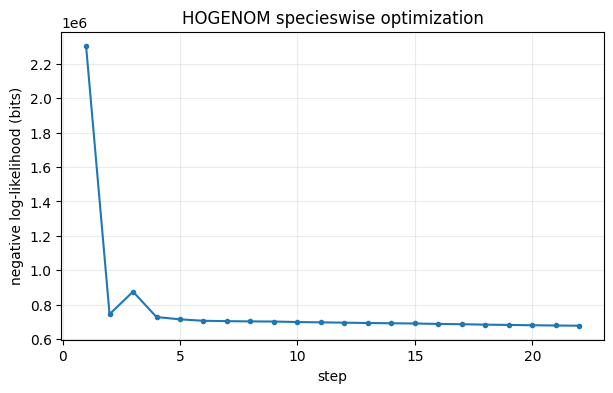

In [ ]:
try:
    import matplotlib.pyplot as plt

    steps = [row["step"] for row in history]
    values = [row["nll_bits"] for row in history]
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(steps, values, marker=".")
    ax.set_xlabel("step")
    ax.set_ylabel("negative log-likelihood (bits)")
    ax.set_title(f"HOGENOM {MODE} optimization")
    ax.grid(alpha=0.25)
    plt.show()
except ImportError:
    print("matplotlib is not installed; skipping plot")

## Inspect fitted event probabilities

In [ ]:
def event_probabilities(theta: torch.Tensor) -> torch.Tensor:
    theta_cpu = theta.detach().cpu()
    zeros = torch.zeros((*theta_cpu.shape[:-1], 1), dtype=theta_cpu.dtype)
    logits = torch.cat((zeros, theta_cpu), dim=-1)
    return torch.softmax(logits * math.log(2.0), dim=-1)

probs = event_probabilities(model.theta)
labels = ["pT", "pS", "pD", "pL"]

if probs.ndim == 1:
    dict(zip(labels, [float(x) for x in probs]))
else:
    summary = {
        label: {
            "mean": float(probs[..., i].mean()),
            "min": float(probs[..., i].min()),
            "max": float(probs[..., i].max()),
        }
        for i, label in enumerate(labels)
    }
    summary

In [ ]:
summary


{'pT': {'mean': 0.8365492224693298, 'min': 0.16342191398143768, 'max': 1.0},
 'pS': {'mean': 0.01075153611600399,
  'min': 2.1635769564820606e-11,
  'max': 0.48516517877578735},
 'pD': {'mean': 0.02326253429055214,
  'min': 3.333333956079265e-11,
  'max': 0.6666664481163025},
 'pL': {'mean': 0.12943673133850098,
  'min': 1.0000006378518833e-10,
  'max': 0.6666666865348816}}

## Save trace and final theta

In [ ]:
OUT_DIR = Path(os.environ.get("GPUREC_OPT_OUT_DIR", HOGENOM_ROOT / "output_gpurec_lean_optimization")).expanduser()
OUT_DIR.mkdir(parents=True, exist_ok=True)

trace_path = OUT_DIR / f"optimization_trace_{MODE}.json"
theta_path = OUT_DIR / f"theta_{MODE}.pt"

trace_path.write_text(json.dumps(history, indent=2) + "\n")
torch.save(model.theta.detach().cpu(), theta_path)

trace_path, theta_path

(PosixPath('/home/enzo/Documents/git/gpurec/gpurec/tests/data/output_gpurec_lean_optimization/optimization_trace_specieswise.json'),
 PosixPath('/home/enzo/Documents/git/gpurec/gpurec/tests/data/output_gpurec_lean_optimization/theta_specieswise.pt'))